<a href="https://colab.research.google.com/github/jrhumberto/2026-mestrado-pep/blob/main/modelo_econometrico_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa para execução de 10 modelos econométricos

>Trata-se de notebook para execução de 2 modelos econométricos (LOGIT e LOGIT CONDICIONAL) em cima do arquivo **painel_uf_2019_2024_austeridade.csv**.



  ---
  **Responsável/Ano**: Humberto Bezerra de M. Júnior - 2026
  
  ---

# Modelos Econométricos de Efeitos Fixos - Dados em Painel


## Panorama  da Gestão Fiscal Responsável nos Estados Brasileiros (mandatos: 2019 até 2022 e 2023-2024)
---
**Detalhamento:** Dez modelos econométricos de efeitos fixos para identificar circunstâncias determinantes de um gestor público do Executivo Estadual que rege sua administração fiscal de forma responsável , baseando-se nos critérios da Lei de Responsabilidade Fiscal (LRF).

**Variável Dependente/Explicativa (Y):** **Gestao_Fiscal_Responsável** (binária: 1 = gestão responsável conforme LRF ou  0 = gestão "esbanjadora" com gastos)

**Critério de Classificação:** A gestão é considerada responsável quando a Despesa Total com Pessoal (DTP) representa até 49% da Receita Corrente Líquida Ajustada (RCLA), conforme limite estabelecido no Art. 20 da LRF.

# (A) Integração de bases para o modelos

> Arquivos extraidos de dimensão fiscal e dimensão eleitoral serão reunidos para consolidar em um único arquivo.

1. Dimensão eleitoral (origem extração do TSE): **eleicoes_uf_2018_2022_austeridade_reeleito_mesmopartido.csv**
2. Dimensão fiscal/econômica (origem extração do SIDRA/SICONFI): **fiscal_uf_2019_2024.csv**


In [2]:
# ======================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ======================================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas para econometria
import statsmodels.api as sm
from scipy import stats

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns



## A.1 - Etapa de Leitura de arquivos
**IMPORTANTE**: Há dois arquivos com extensão .csv: um com dimensão eleitoral em que consta as 3 variáveis 'austeridade', 'mesmopartido' e 'reeleito' e outro com a dimensão fiscal, com dados da gestão do mandato do eleito.


Dimensão eleitoral: eleicoes_uf_2018_2022_austeridade_reeleito_mesmopartido.csv

Dimensão fiscal: fiscal_uf_2019_2024.csv

In [23]:

df_eleitoral = pd.read_csv('https://raw.githubusercontent.com/jrhumberto/2026-mestrado-pep/refs/heads/main/data/eleitoral_uf_2018_2022_austeridade_reeleito_mesmopartido.csv')

df_fiscal = pd.read_csv('https://raw.githubusercontent.com/jrhumberto/2026-mestrado-pep/refs/heads/main/data/fiscal_uf_2019_2024.csv')


# Por default, eu já crio as colunas vazias no dataset fiscal.
df_fiscal['austeridade'] = np.nan
df_fiscal['mesmopartido'] = np.nan
df_fiscal['reeleito'] = np.nan


df_eleitoral.head(10)

,SG_UF,ANO_ELEICAO,DS_CARGO,NM_CANDIDATO,SG_PARTIDO,austeridade,reeleito,mesmopartido
0,AC,2018,GOVERNADOR,GLADSON DE LIMA CAMELI,PP,1,0,0
1,AC,2022,GOVERNADOR,GLADSON DE LIMA CAMELI,PP,1,1,1
2,AL,2018,GOVERNADOR,JOSE RENAN VASCONCELOS CALHEIROS FILHO,MDB,1,1,1
3,AL,2022,GOVERNADOR,PAULO SURUAGY DO AMARAL DANTAS,MDB,1,0,1
4,AM,2018,GOVERNADOR,WILSON MIRANDA LIMA,PSC,1,0,0
5,AM,2022,GOVERNADOR,WILSON MIRANDA LIMA,UNIÃO,1,1,0
6,AP,2018,GOVERNADOR,ANTONIO WALDEZ GÓES DA SILVA,PDT,0,0,1
7,AP,2022,GOVERNADOR,CLÉCIO LUÍS VILHENA VIEIRA,SOLIDARIEDADE,1,0,0
8,BA,2018,GOVERNADOR,RUI COSTA DOS SANTOS,PT,0,1,1
9,BA,2022,GOVERNADOR,JERÔNIMO RODRIGUES SOUZA,PT,0,0,1


In [24]:

df_fiscal.head(10)

,uf,ano,dcl,pop,pib_prc,rcl,rcla,dtp,percentual_dtp_rcla,austeridade,mesmopartido,reeleito
0,AC,2019,3.116892e+09,869265,1.563002e+10,5.357456e+09,5.357456e+09,2.878921e+09,53.74,NaN,NaN,NaN
1,AC,2020,3.337030e+09,881935,1.647637e+10,5.702871e+09,5.702871e+09,3.004991e+09,52.69,NaN,NaN,NaN
2,AC,2021,2.847799e+09,894470,2.137444e+10,6.690646e+09,6.651120e+09,3.421543e+09,51.44,NaN,NaN,NaN
3,AC,2022,2.505322e+09,906876,2.367614e+10,7.994707e+09,7.968319e+09,3.694040e+09,46.36,NaN,NaN,NaN
4,AC,2023,2.051524e+09,906876,2.629132e+10,8.573004e+09,8.496046e+09,4.113347e+09,48.41,NaN,NaN,NaN
5,AC,2024,1.978575e+09,829780,0.000000e+00,1.011123e+10,1.000246e+10,4.678325e+09,46.77,NaN,NaN,NaN
6,AL,2019,6.404122e+09,3322820,5.896373e+10,8.559007e+09,8.559007e+09,3.826568e+09,44.71,NaN,NaN,NaN
7,AL,2020,5.813490e+09,3337357,6.320235e+10,1.005950e+10,1.004934e+10,3.997128e+09,39.78,NaN,NaN,NaN
8,AL,2021,4.758264e+09,3351543,7.626562e+10,1.252891e+10,1.246151e+10,4.436804e+09,35.60,NaN,NaN,NaN
9,AL,2022,7.245315e+09,3365351,7.606581e+10,1.317791e+10,1.314893e+10,5.378105e+09,40.90,NaN,NaN,NaN


## A.2 - Geração da variável 'austeridade'
> Verifica se o candidato vencedor é do agremiação partidária que defende austeridade das contas a partir da dimensão eleitoral. Na sequência, apenas constata-se se o resultado do pleito 2022 foi copiado corretamente nos anos fiscais de 2023 e 2024, por exemplo.

In [25]:
# Compara com o conteúdo do arquivo eleitoral
import numpy as np
lista_anos = list(df_fiscal.ano.unique())
lista_uf = list(df_fiscal.uf.unique())

lista_UF_2018_austeridade_eleito = df_eleitoral[ (df_eleitoral.austeridade == 1) & (df_eleitoral.ANO_ELEICAO == 2018)]['SG_UF'].unique()
lista_UF_2022_austeridade_eleito = df_eleitoral[ (df_eleitoral.austeridade == 1) & (df_eleitoral.ANO_ELEICAO == 2022)]['SG_UF'].unique()

grupo_austeridade_eleito = {
    2018: lista_UF_2018_austeridade_eleito,
    2022: lista_UF_2022_austeridade_eleito
}


# Para quaisquer casos, todos zerados no inicio
df_fiscal['austeridade'] = 0

# Para cada UF e ano , verificar se o ano de mandato corresponde ao pleito de 2018 ou 2022 e se austero
for uf in lista_uf:
  for ano in lista_anos:
      esta_grupo_austeridade = (( ((2018 < ano <= 2022) and (uf in grupo_austeridade_eleito[2018]) ) or ((ano > 2022)  and (uf in grupo_austeridade_eleito[2022])) ))
      if esta_grupo_austeridade:
          df_fiscal.loc[ (df_fiscal['uf'] == uf) & (df_fiscal['ano'] == ano), 'austeridade'] = int(esta_grupo_austeridade)




df_fiscal.head(50)

,uf,ano,dcl,pop,pib_prc,rcl,rcla,dtp,percentual_dtp_rcla,austeridade,mesmopartido,reeleito
0,AC,2019,3.116892e+09,869265,1.563002e+10,5.357456e+09,5.357456e+09,2.878921e+09,53.74,1,NaN,NaN
1,AC,2020,3.337030e+09,881935,1.647637e+10,5.702871e+09,5.702871e+09,3.004991e+09,52.69,1,NaN,NaN
2,AC,2021,2.847799e+09,894470,2.137444e+10,6.690646e+09,6.651120e+09,3.421543e+09,51.44,1,NaN,NaN
3,AC,2022,2.505322e+09,906876,2.367614e+10,7.994707e+09,7.968319e+09,3.694040e+09,46.36,1,NaN,NaN
4,AC,2023,2.051524e+09,906876,2.629132e+10,8.573004e+09,8.496046e+09,4.113347e+09,48.41,1,NaN,NaN
5,AC,2024,1.978575e+09,829780,0.000000e+00,1.011123e+10,1.000246e+10,4.678325e+09,46.77,1,NaN,NaN
6,AL,2019,6.404122e+09,3322820,5.896373e+10,8.559007e+09,8.559007e+09,3.826568e+09,44.71,1,NaN,NaN
7,AL,2020,5.813490e+09,3337357,6.320235e+10,1.005950e+10,1.004934e+10,3.997128e+09,39.78,1,NaN,NaN
8,AL,2021,4.758264e+09,3351543,7.626562e+10,1.252891e+10,1.246151e+10,4.436804e+09,35.60,1,NaN,NaN
9,AL,2022,7.245315e+09,3365351,7.606581e+10,1.317791e+10,1.314893e+10,5.378105e+09,40.90,1,NaN,NaN


In [26]:
df_eleitoral[(df_eleitoral['ANO_ELEICAO']==2022)]['austeridade'].value_counts()

,count
austeridade,
0,14
1,13


In [27]:
df_fiscal[(df_fiscal['ano']==2023)]['austeridade'].value_counts()

,count
austeridade,
0,14
1,13


In [28]:
df_fiscal[(df_fiscal['ano']==2024)]['austeridade'].value_counts()

,count
austeridade,
0,14
1,13


## A.3 - Geração da variável 'mesmopartido'

>Verifica se o candidato vencedor é do mesmo partido do governador anterior a partir da dimensão eleitoral. Na sequência, apenas é feita uma checagem se o resultado do pleito 2022 foi copiado corretamente nos anos fiscais de 2023 e 2024, por exemplo.

In [29]:
grupo_mesmopartido = {
    2018: df_eleitoral[ (df_eleitoral.mesmopartido == 1) & (df_eleitoral.ANO_ELEICAO == 2018)]['SG_UF'].unique(),
    2022: df_eleitoral[ (df_eleitoral.mesmopartido == 1) & (df_eleitoral.ANO_ELEICAO == 2022)]['SG_UF'].unique()
}

# Para quaisquer casos, todos zerados no inicio
df_fiscal['mesmopartido'] = 0

for uf in lista_uf:
  for ano in lista_anos:
      esta_grupo_mesmopartido = (( ((2018 < ano <= 2022) and (uf in grupo_mesmopartido[2018]) ) or ((ano > 2022)  and (uf in grupo_mesmopartido[2022])) ))
      if esta_grupo_mesmopartido:
          df_fiscal.loc[ (df_fiscal['uf'] == uf) & (df_fiscal['ano'] == ano), 'mesmopartido'] = int(esta_grupo_mesmopartido)

In [30]:
df_eleitoral[(df_eleitoral['ANO_ELEICAO']==2022)]['mesmopartido'].value_counts()

,count
mesmopartido,
1,15
0,12


In [31]:
df_fiscal[(df_fiscal['ano']==2023)]['mesmopartido'].value_counts()

,count
mesmopartido,
1,15
0,12


In [32]:

df_fiscal[(df_fiscal['ano']==2024)]['mesmopartido'].value_counts()

,count
mesmopartido,
1,15
0,12


## A.4 - Geração da variável 'reeleito'

>Verifica se o candidato vencedor foi reeleito a partir da dimensão eleitoral. Na sequência, apenas é feita uma checagem se o resultado de pleito 2022 foi copiado corretamente nos anos fiscais de 2023 e 2024, por exemplo.

In [33]:

grupo_reeleito = {
    2018: df_eleitoral[ (df_eleitoral.reeleito == 1) & (df_eleitoral.ANO_ELEICAO == 2018)]['SG_UF'].unique(),
    2022: df_eleitoral[ (df_eleitoral.reeleito == 1) & (df_eleitoral.ANO_ELEICAO == 2022)]['SG_UF'].unique()
}

# Para quaisquer casos, todos zerados no inicio
df_fiscal['reeleito'] = 0

# Para cada UF e ano , verificar se o ano de mandato corresponde ao pleito de 2018 ou 2022 e se austero
for uf in lista_uf:
  for ano in lista_anos:
      esta_grupo_reeleito = (( ((2018 < ano <= 2022) and (uf in grupo_reeleito[2018]) ) or ((ano > 2022)  and (uf in grupo_reeleito[2022])) ))
      if esta_grupo_reeleito:
          df_fiscal.loc[ (df_fiscal['uf'] == uf) & (df_fiscal['ano'] == ano), 'reeleito'] = int(esta_grupo_reeleito)

In [34]:
df_eleitoral[(df_eleitoral['ANO_ELEICAO']==2022)]['reeleito'].value_counts()

,count
reeleito,
0,16
1,11


In [21]:

df_fiscal[(df_fiscal['ano']==2023)]['reeleito'].value_counts()


,count
reeleito,
0,16
1,11


In [35]:

df_fiscal[(df_fiscal['ano']==2024)]['reeleito'].value_counts()

,count
reeleito,
0,16
1,11


## A.5 - Correspondência e Checagens entre dimensão eleitoral e dimensão fiscal

* Na dimensão eleitoral há apenas 54 linhas (27 UF e anos 2018 e 2022).

* Na dimensão fiscal há 162 linhas (27 UF e anos: 2019, 2020, 2021, 2022, 2023 e 2024)

- Para cada linha das 3 variáveis eleitorais no ano de 2018, 4 linhas correspondentes(2019-2022) na dimensão fiscal terão o mesmo valor.

- Para cada linha das 3 variáveis fiscais no ano de 2022, 2 linhas correspondentes(2023-2024) na dimensão fiscal terão o mesmo valor.

>A.5.1. Pega os valores das 3 variáveis na dimensão eleitoral em 2018 e 2022.

>A.5.2. Pega os valores das mesmas 3 variáveis na dimensão fiscal no mandato1(2019-2022) compara com a dimensão eleitoral no ano 2018. No mandato2(2023,2024), compara com resultado eleitoral de 2022. Todas 3 variáveis tem que possuir mesmo valor.

In [36]:
#  4A - Pegando os valores da dimensão eleitoral das 3 variáveis em 2018 e 2022
k, v = [], []
for ano in [2018, 2022]:
  for var in ['austeridade', 'mesmopartido', 'reeleito']:
      k.append(f"qtd_{var}_{ano}")
      v.append(df_eleitoral.loc[df_eleitoral["ANO_ELEICAO"] == ano, var].value_counts())


placar_eleitoral = dict(zip(k, v))
lista_vars = ['austeridade', 'reeleito', 'mesmopartido']

# 4B Pega os valores em 2019 até 2024 e compara com o respectivo pleito eleitoral (2018 ou 2022)
for ano in lista_anos:
    for var in lista_vars:
        qtd_fiscal = tuple(df_fiscal.loc[df_fiscal["ano"] == ano, var].value_counts().values)
        y = 2018 if (ano <= 2022) else 2022
        qtd_eleitoral = tuple(placar_eleitoral[f"qtd_{var}_{y}"].values)
        if qtd_eleitoral != qtd_fiscal:
            print(f"Houve divergência de Valores no Ano: {ano} - Variável: {var}\n")
            print(f"Qtd_eleitoral: 0: {qtd_eleitoral[0]}, 1: {qtd_eleitoral[0]} \n")
            print(f"Qtd_fiscal: 0: {qtd_eleitoral[0]}, 1: {qtd_eleitoral[0]} \n")
            break
    else:
        print(f"Não houve divergência de Valores no Ano: {ano}\n")

Não houve divergência de Valores no Ano: 2019

Não houve divergência de Valores no Ano: 2020

Não houve divergência de Valores no Ano: 2021

Não houve divergência de Valores no Ano: 2022

Não houve divergência de Valores no Ano: 2023

Não houve divergência de Valores no Ano: 2024



## A.6 - Criação da váriável Y (dependente)

Gestão_Fiscal_Responsável = 1 se (dtp/rcla < 49%) e 0 , em caso contrário.

In [37]:
df_fiscal.head(10)

,uf,ano,dcl,pop,pib_prc,rcl,rcla,dtp,percentual_dtp_rcla,austeridade,mesmopartido,reeleito
0,AC,2019,3.116892e+09,869265,1.563002e+10,5.357456e+09,5.357456e+09,2.878921e+09,53.74,1,0,0
1,AC,2020,3.337030e+09,881935,1.647637e+10,5.702871e+09,5.702871e+09,3.004991e+09,52.69,1,0,0
2,AC,2021,2.847799e+09,894470,2.137444e+10,6.690646e+09,6.651120e+09,3.421543e+09,51.44,1,0,0
3,AC,2022,2.505322e+09,906876,2.367614e+10,7.994707e+09,7.968319e+09,3.694040e+09,46.36,1,0,0
4,AC,2023,2.051524e+09,906876,2.629132e+10,8.573004e+09,8.496046e+09,4.113347e+09,48.41,1,1,1
5,AC,2024,1.978575e+09,829780,0.000000e+00,1.011123e+10,1.000246e+10,4.678325e+09,46.77,1,1,1
6,AL,2019,6.404122e+09,3322820,5.896373e+10,8.559007e+09,8.559007e+09,3.826568e+09,44.71,1,1,1
7,AL,2020,5.813490e+09,3337357,6.320235e+10,1.005950e+10,1.004934e+10,3.997128e+09,39.78,1,1,1
8,AL,2021,4.758264e+09,3351543,7.626562e+10,1.252891e+10,1.246151e+10,4.436804e+09,35.60,1,1,1
9,AL,2022,7.245315e+09,3365351,7.606581e+10,1.317791e+10,1.314893e+10,5.378105e+09,40.90,1,1,1


In [38]:
df_fiscal['gestao_fiscal_responsavel'] = np.where((df_fiscal.dtp/df_fiscal.rcla)<0.49, 1, 0)

In [39]:
df_fiscal.head(10)

,uf,ano,dcl,pop,pib_prc,rcl,rcla,dtp,percentual_dtp_rcla,austeridade,mesmopartido,reeleito,gestao_fiscal_responsavel
0,AC,2019,3.116892e+09,869265,1.563002e+10,5.357456e+09,5.357456e+09,2.878921e+09,53.74,1,0,0,0
1,AC,2020,3.337030e+09,881935,1.647637e+10,5.702871e+09,5.702871e+09,3.004991e+09,52.69,1,0,0,0
2,AC,2021,2.847799e+09,894470,2.137444e+10,6.690646e+09,6.651120e+09,3.421543e+09,51.44,1,0,0,0
3,AC,2022,2.505322e+09,906876,2.367614e+10,7.994707e+09,7.968319e+09,3.694040e+09,46.36,1,0,0,1
4,AC,2023,2.051524e+09,906876,2.629132e+10,8.573004e+09,8.496046e+09,4.113347e+09,48.41,1,1,1,1
5,AC,2024,1.978575e+09,829780,0.000000e+00,1.011123e+10,1.000246e+10,4.678325e+09,46.77,1,1,1,1
6,AL,2019,6.404122e+09,3322820,5.896373e+10,8.559007e+09,8.559007e+09,3.826568e+09,44.71,1,1,1,1
7,AL,2020,5.813490e+09,3337357,6.320235e+10,1.005950e+10,1.004934e+10,3.997128e+09,39.78,1,1,1,1
8,AL,2021,4.758264e+09,3351543,7.626562e+10,1.252891e+10,1.246151e+10,4.436804e+09,35.60,1,1,1,1
9,AL,2022,7.245315e+09,3365351,7.606581e+10,1.317791e+10,1.314893e+10,5.378105e+09,40.90,1,1,1,1


## A.7 - Criação do Painel em formato csv

In [42]:
import os

# Criar o diretório 'data' se ele não existir
os.makedirs('./data', exist_ok=True)

df_fiscal.to_csv('./data/painel_uf_2019_2024_completo.csv', index=False)

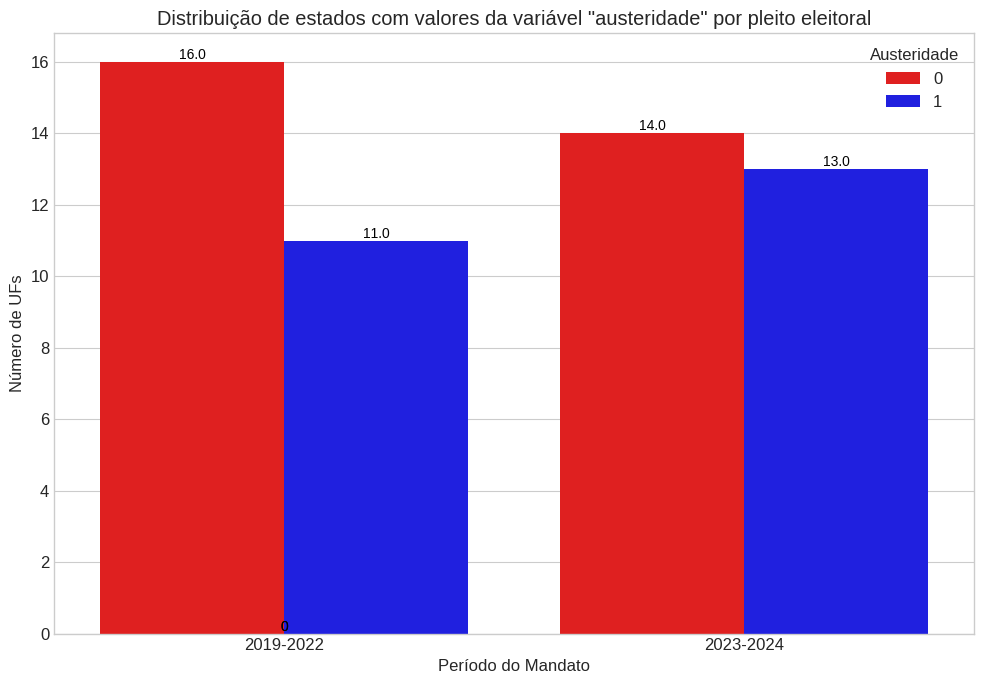

In [57]:
# Distribuição da varíavel de Austeridade
df_fiscal['mandate_period'] = '2019-2022'
df_fiscal.loc[df_fiscal['ano'] >= 2023, 'mandate_period'] = '2023-2024'
df_unique_uf_gr = df_fiscal.groupby(['uf', 'mandate_period'])['austeridade'].first().reset_index()

plt.figure(figsize=(10, 7))
ax = sns.countplot(data=df_unique_uf_gr, x='mandate_period', hue='austeridade', palette={0: 'red', 1: 'blue'})

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribuição de estados com valores da variável "austeridade" por pleito eleitoral')
plt.xlabel('Período do Mandato')
plt.ylabel('Número de UFs')
plt.legend(title='Austeridade')
plt.tight_layout()
plt.show()

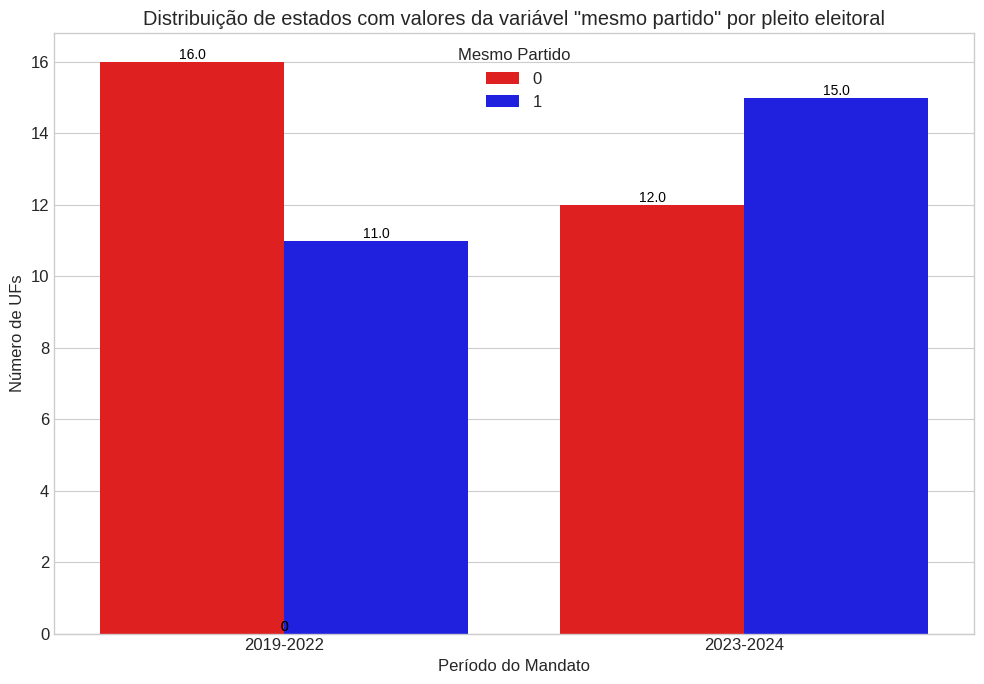

In [56]:
# Distribuição da varíavel de Mesmo Partido
df_fiscal['pleito'] = '2019-2022'
df_fiscal.loc[df_fiscal['ano'] >= 2023, 'pleito'] = '2023-2024'
df_unique_uf_gr = df_fiscal.groupby(['uf', 'pleito'])['mesmopartido'].first().reset_index()

plt.figure(figsize=(10, 7))
ax = sns.countplot(data=df_unique_uf_gr, x='pleito', hue='mesmopartido', palette={0: 'red', 1: 'blue'})

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribuição de estados com valores da variável "mesmo partido" por pleito eleitoral')
plt.xlabel('Período do Mandato')
plt.ylabel('Número de UFs')
plt.legend(title='Mesmo Partido')
plt.tight_layout()
plt.show()

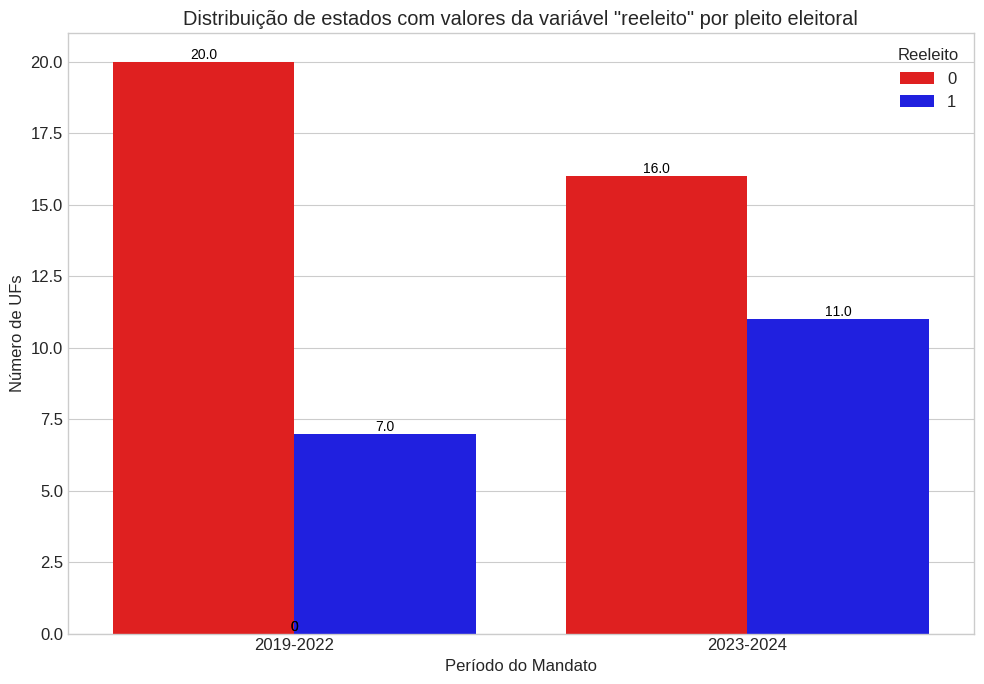

In [55]:
# Distribuição da varíavel de Mesmo Partido
df_fiscal['pleito'] = '2019-2022'
df_fiscal.loc[df_fiscal['ano'] >= 2023, 'pleito'] = '2023-2024'
df_unique_uf_gr = df_fiscal.groupby(['uf', 'pleito'])['reeleito'].first().reset_index()

plt.figure(figsize=(10, 7))
ax = sns.countplot(data=df_unique_uf_gr, x='pleito', hue='reeleito', palette={0: 'red', 1: 'blue'})

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribuição de estados com valores da variável "reeleito" por pleito eleitoral')
plt.xlabel('Período do Mandato')
plt.ylabel('Número de UFs')
plt.legend(title='Reeleito')
plt.tight_layout()
plt.show()

# (B) Execução Econométrica

In [61]:
# Limites de Visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# ======================================================================
# CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ======================================================================
# Carregar o dataset
df = pd.read_csv('https://raw.githubusercontent.com/jrhumberto/2026-mestrado-pep/refs/heads/main/data/painel_uf_2019_2024_completo.csv')

print(df.describe())

               ano           dcl           pop       pib_prc           rcl  \
count   162.000000  1.620000e+02  1.620000e+02  1.620000e+02  1.620000e+02   
mean   2021.500000  3.055441e+10  7.807304e+06  2.779870e+11  3.403981e+10   
std       1.713121  6.539933e+10  9.145193e+06  5.167868e+11  4.024348e+10   
min    2019.000000 -7.186553e+09  5.765680e+05  0.000000e+00  4.200526e+09   
25%    2020.000000  1.819053e+09  2.839188e+06  2.672352e+10  1.231633e+10   
50%    2021.500000  5.301876e+09  4.059905e+06  1.121001e+11  2.209862e+10   
75%    2023.000000  1.323936e+10  9.432366e+06  2.734624e+11  3.816458e+10   
max    2024.000000  3.176556e+11  4.664913e+07  3.444814e+12  2.513670e+11   

               rcla           dtp  percentual_dtp_rcla  austeridade  \
count  1.620000e+02  1.620000e+02           162.000000   162.000000   
mean   3.397402e+10  1.464260e+10            43.303951     0.432099   
std    4.018673e+10  1.718791e+10             5.149625     0.496904   
min    4.2005

## 1. Principais colunas do arquivo base do Problema


### 1.1 Variável Dependente (Y): Gestao_Fiscal_Responsável

A variável dependente binária **Gestao_Fiscal_Responsável** é fictícia e criada com base nos critérios estabelecidos pela Lei de Responsabilidade Fiscal (LRF):

- **Gestao_Fiscal_Responsável = 1**: Quando a Despesa Total com Pessoal (DTP) representa até 49% da Receita Corrente Líquida Ajustada (RCLA), conforme Art. 20 da LRF
- **Gestao_Fiscal_Responsável = 0**: Quando a DTP supera 49% da RCLA, indicando descumprimento do limite legal.



>IMPORTANTE: Observa-se que esta Y é altamente relacionada a três colunas do dataset: dtp, rcla e percentual_dtp_rcla. **Basicamente não faz sentido essas 3 colunas continuarem no dataset, portanto serão eliminadas do modelo pois já explicam diretamente o cálculo de Y**


  


### 1.2 Variáveis Independentes

1. **Dívida Consolidada Líquida** (*dcl*) — valor absoluto da dívida menos disponibilidades (recursos em curto prazo disponíveis em caixa/estoque do governo). Proveniente do Anexo 2 do RGF.
1. **População do Estado no Ano** ( *pop* ) - trata-se da população que foi informada pelo Ente no RGF daquele ano.
1. **PIB de Preços Correntes** ( *pib_prec_corr* ) - trata-se de PIB de todas as receitas e riquezas apuradas pelo ente naquele ano. Dado extraído do SIDRA/IBGE, por isso o dado do ano 2024 está ainda indisponível até o presente momento da pesquisa. Na falta do dado do ano de 2024, atribuído valor 0.
1. **Receita Corrente Líquida** ( rcl ) - trata-se de valor absoluto da Receita Corrente Líquida do ente.
1. **Receita Corrente Líquida Ajustada** ( rcla ) - trata-se do valor de  Receita Corrente Líquida reduzido do montante de Transferências Obrigatórias da União Relativas às Emendas Individuais (art. 166-A, §1º, da CF).
1. **Despesa Total com Pessoal** (dtp) - Somatório de gastos com pessoal.
1. **Despesa Total com Pessoal como % da RCLA** (dtp_perc_rcla) - Razão entre a despesa total com pessoal (dtp) em relação ao valor da Receita Corrente Líquida Ajustada (rcla) em percentual. Proxy de rigidez fiscal embasado em norma (art. 20 e 22, da LRF), que estabelece governadores não podem comprometer mais de 49%

1. **Mesmo Partido** (dummy mesmopartido) é uma variável que compara se o atual vencedor é do mesmo partido do governador anterior. Na prática, ela será valor 1 se sim, casos em que ele se reelegeu ou elegeu seu sucessor. Se for candidato vencedor de outro partido será 0.
1. **Reeleito** (dummy reeleito) é uma variável que comparará o mandato anterior e se o candidato é o mesmo que já era governador antes, o que denota que já havia experiência no cargo. Se sim , ela terá valor 1. Caso contrário, será valor 0.

1. **Austeridade** ( austeridade ) é uma variável exógena ao contexto de gestão fiscal e sim trazida do resultado do pleito eleitoral de 2018 e de 2022. Ela  será 1 se o governador eleito for dos seguintes partidos abaixo e 0 nos demais casos:
- PSDB
- DEM
- UNIÂO BRASIL
- PP
- SOLIDARIEDADE (SD)
- CIDADANIA (CD)
- MDB
- PTB
- PSC
- PODEMOS


### 1.3 Distribuição da variável Y (Gestão Fiscal Responsável) por ano e por estado.

In [62]:
# =============================================================================
# CRIAÇÃO DA VARIÁVEL DEPENDENTE
# =============================================================================
# Configuração de estilo para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Remoção das colunas especificadas que vão gerar a coluna Y
cols_to_drop = ['rcla', 'dtp', 'percentual_dtp_rcla']
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dimensões do dataset: {df.shape}")
print(f"Estados: {df['uf'].nunique()}, Anos: {df['ano'].nunique()}")

# Verificar a distribuição de Y
print("=" * 80)
print("DISTRIBUIÇÃO DA VARIÁVEL DEPENDENTE")
print("=" * 80)
print("\n Porcentagem de gestão responsável = 1, a cada ano:")
print((df.groupby('ano')['gestao_fiscal_responsavel'].mean() * 100))

print("\n Divisão Por ano (valor absoluto):")
print(df.groupby('ano')['gestao_fiscal_responsavel'].value_counts().unstack(fill_value=0))



Dimensões do dataset: (162, 10)
Estados: 27, Anos: 6
DISTRIBUIÇÃO DA VARIÁVEL DEPENDENTE

 Porcentagem de gestão responsável = 1, a cada ano:
ano
2019    77.777778
2020    85.185185
2021    92.592593
2022    96.296296
2023    88.888889
2024    96.296296
Name: gestao_fiscal_responsavel, dtype: float64

 Divisão Por ano (valor absoluto):
gestao_fiscal_responsavel  0   1
ano                             
2019                       6  21
2020                       4  23
2021                       2  25
2022                       1  26
2023                       3  24
2024                       1  26


## 2. Transformações de Variáveis

**Sugere-se dois modelos econométricos LOGIT em que as seguintes tranformações serão necessárias na base ou em variáveis**

### 2.1 Sem Eliminação da base de PIB a preços correntes zerados.
- Ocorre no ano de 2024 que este indicador não está disponível, portanto ou trabalha-se com PIB defasado a ano anterior ou elimina-se linhas em que o PIB a preços correntes é zero. Será feita abordagem de especificamente no ano de 2024 que não temos o valor de PIB a preços correntes ser considerado o valor do ano anterior. Nos demais anos, será considerado o valor do respectivo ano.


### 2.2. Transformações Logarítmicas:
Utilizadas para lidar com valores muito grandes e reduzir a heterocedasticidade, no caso duas variáveis estão em escala muito maior que as demais e serão aplicadas transformação logarítmica nelas:
- **log_rcl** = log(rcl)
- **log_pop** = log(pop)
- **log_pib** = log(pib_prc)


### 2.3. Transformação do Dívida Consolidada Líquida
Conisiderando dado negativo que ocorre em Dívida Consolidada Líquida, não trata-se de uma "leitura suja" ou incongruência e sim um fator benéfico no qual um ente inda terá uma margem para se endividar ,ou seja, é um indicador de "saúde" das contas públicas. Portanto, para reduzir a escala da varíavel será substituída por uma razão entre a DCL e RCL
- **dcl_rcl** = DCL / RCL



### 2.4 Variáveis de Controle Não Fiscais mantidas
- **austeridade** (variável exógena da dimensão fiscal)
- **reeleito** (variável exógena da dimensão fiscal, uma dummy que mede representa experiência do gestor)
- **mesmopartido** (variável exógena, uma dummy que aponta para o passado , se o grupo político se perpetuou via mesmo governador ou novo partidário eleito)


### 2.5 Eliminação da base de colunas que já definem Y.
- Eliminados percentual_dtp_rcla, dtp e rcla.

In [63]:
# =============================================================================
# TRANSFORMAÇÕES DE VARIÁVEIS
# =============================================================================
# === TRATAMENTO DE VARIÁVEIS ECONÔMICAS ===

# PIB: tratar valores 0 em 2024 (dados não disponibilizados)
# Estratégia: usar forward fill por estado para pegar o valor de 2023 do PIB.
df['pib_missing_2024'] = (df['ano'] == 2024) & (df['pib_prc'] == 0)
df.loc[df['pib_prc'] == 0, 'pib_prc'] = np.nan
df['pib_prc'] = df.groupby('uf')['pib_prc'].transform(lambda x: x.fillna(method='ffill'))

# Transformações logarítmicas APENAS para variáveis estritamente positivas
df['log_pib'] = np.log(df['pib_prc'])
df['log_rcl'] = np.log(df['rcl'])
df['log_pop'] = np.log(df['pop'])

# Transformação de  DCL (ela pode ser negativa e deve ser modelada)
# Usar dcl relativo à receita (proporção) - mais interpretável
df['dcl_rcl'] = df['dcl'] / df['rcl']  # Pode ser negativo, mas em escala [-1, 1] aproximadamente

# Criação de dummies para ano (efeitos temporais)
df = pd.get_dummies(df, columns=['ano'], prefix='ano', drop_first=True)

# Remoção de observações com missing nas variáveis essenciais
df_model = df.dropna(subset=['gestao_fiscal_responsavel', 'dcl_rcl', 'log_pib', 'log_rcl', 'log_pop',
                              'austeridade', 'mesmopartido', 'reeleito']).copy()

print(f"\nObservações para o modelo: {len(df_model)}")
print(f"\nDistribuição da variável dependente:")
print(df_model['gestao_fiscal_responsavel'].value_counts(normalize=True) * 100)

# Verificação de valores extremos em dcl_rcl
print(f"\nEstatísticas de dcl_rcl (Razão entre Dívida Corrente Líquida e Receita Corrente Líquida):")
print(df_model['dcl_rcl'].describe())


Observações para o modelo: 162

Distribuição da variável dependente:
gestao_fiscal_responsavel
1    89.506173
0    10.493827
Name: proportion, dtype: float64

Estatísticas de dcl_rcl (Razão entre Dívida Corrente Líquida e Receita Corrente Líquida):
count    162.000000
mean       0.504814
std        0.624196
min       -0.244650
25%        0.119062
50%        0.328519
75%        0.546240
max        3.190334
Name: dcl_rcl, dtype: float64


In [69]:
# Tabela descritiva das variáveis principais
vars_desc = ['dcl', 'dcl_rcl', 'pib_prc', 'rcl', 'pop',
             'austeridade', 'mesmopartido', 'reeleito', 'gestao_fiscal_responsavel']

print("\n" + "="*80)
print("ESTATÍSTICA DESCRITIVA")
print("="*80)
print(df_model[vars_desc].describe(), "\n\n\n")


ESTATÍSTICA DESCRITIVA
                dcl     dcl_rcl       pib_prc           rcl           pop  \
count  1.620000e+02  162.000000  1.620000e+02  1.620000e+02  1.620000e+02   
mean   3.055441e+10    0.504814  3.455385e+11  3.403981e+10  7.807304e+06   
std    6.539933e+10    0.624196  5.703543e+11  4.024348e+10  9.145193e+06   
min   -7.186553e+09   -0.244650  1.429223e+10  4.200526e+09  5.765680e+05   
25%    1.819053e+09    0.119062  7.055322e+10  1.231633e+10  2.839188e+06   
50%    5.301876e+09    0.328519  1.726458e+11  2.209862e+10  4.059905e+06   
75%    1.323936e+10    0.546240  3.461430e+11  3.816458e+10  9.432366e+06   
max    3.176556e+11    3.190334  3.444814e+12  2.513670e+11  4.664913e+07   

       austeridade  mesmopartido    reeleito  gestao_fiscal_responsavel  
count   162.000000    162.000000  162.000000                 162.000000  
mean      0.432099      0.456790    0.308642                   0.895062  
std       0.496904      0.499674    0.463365                

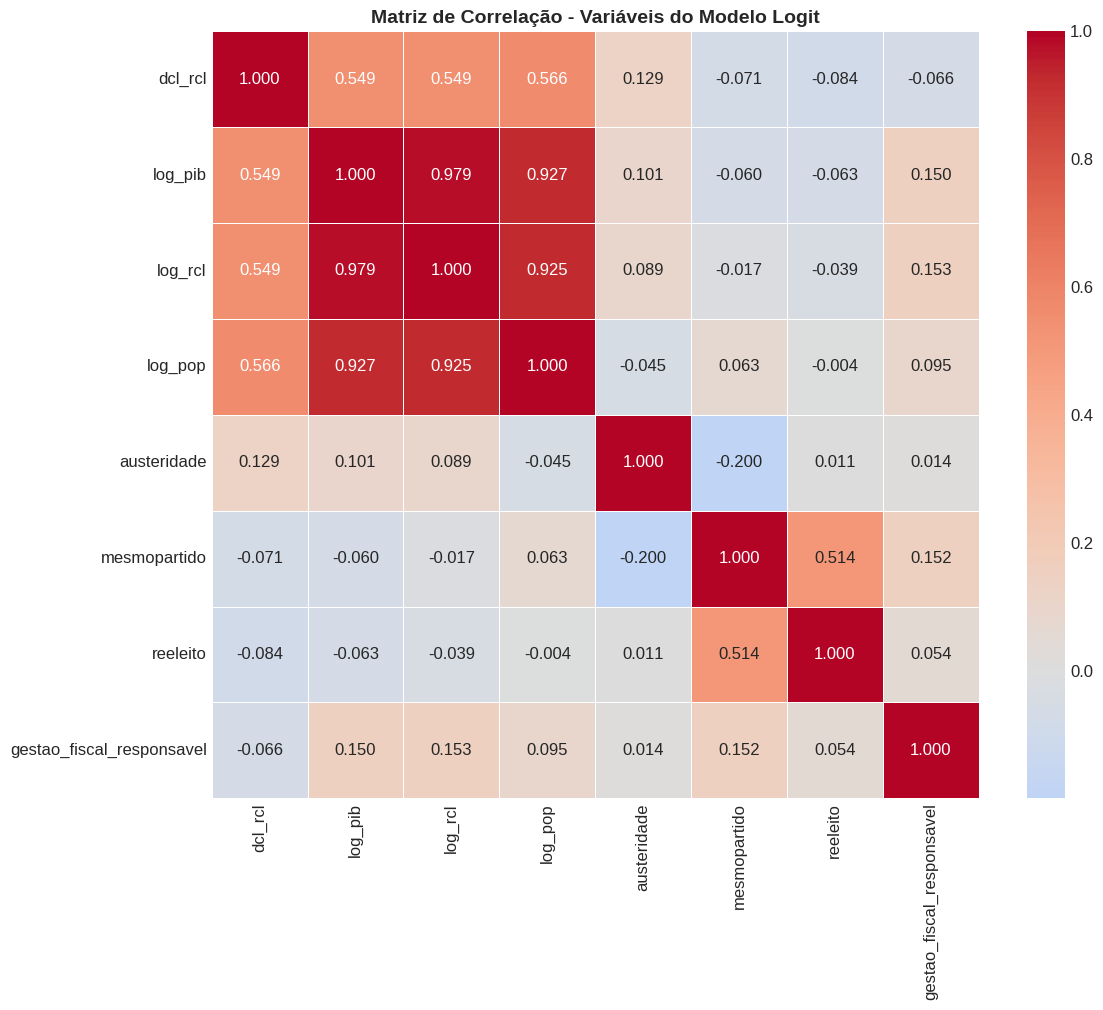

In [68]:
# Matriz de correlação (variáveis numéricas)
numeric_vars = ['dcl_rcl', 'log_pib', 'log_rcl', 'log_pop',
                'austeridade', 'mesmopartido', 'reeleito', 'gestao_fiscal_responsavel']
corr_matrix = df_model[numeric_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlação - Variáveis do Modelo Logit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_logit.png', dpi=300, bbox_inches='tight')
plt.show()

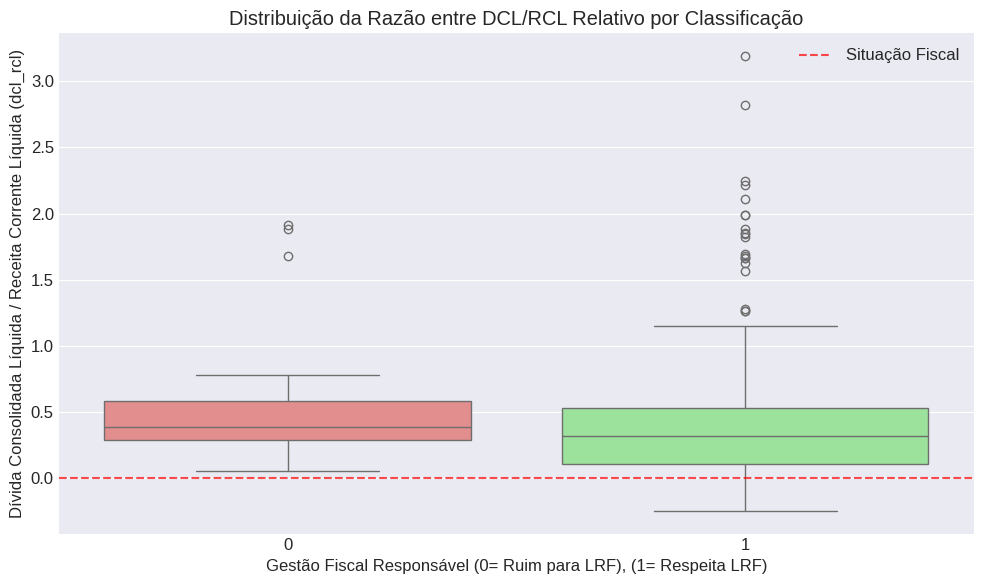

In [73]:
# Boxplot de dcl_receita por gestão fiscal responsável
plt.figure(figsize=(10, 6))
sns.boxplot(x='gestao_fiscal_responsavel', y='dcl_rcl', data=df_model, palette=['lightcoral', 'lightgreen'])
plt.xlabel('Gestão Fiscal Responsável (0= Ruim para LRF), (1= Respeita LRF)')
plt.ylabel('Dívida Consolidada Líquida / Receita Corrente Líquida (dcl_rcl)')
plt.title('Distribuição da Razão entre DCL/RCL Relativo por Classificação')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Situação Fiscal')
plt.legend()
plt.tight_layout()
plt.savefig('dcl_receita_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Especificação e resultados de modelos

### 3.1 Modelo 1 : Logit Efeito Fixo

> Desconsidera o formato em Painel da base, portanto cada observação é uma linha independente.

In [74]:
# Definição das variáveis independentes
vars = ['dcl_rcl', 'log_pib', 'log_rcl', 'log_pop','austeridade', 'mesmopartido', 'reeleito']

# Variaveis Dummy de anos
vars += [col for col in df_model.columns if col.startswith('ano_')]

X = sm.add_constant(df_model[vars])

# Correção: Converter colunas booleanas de 'ano_' para int (0 ou 1)
for col in [col for col in X.columns if col.startswith('ano_')]:
    X[col] = X[col].astype(int)


y = df_model['gestao_fiscal_responsavel']

# Estimação do modelo Logit com erros robustos clusterizados por UF
# (importante para dados em painel)
logit_model = sm.Logit(y, X)
logit_results = logit_model.fit(cov_type='cluster', cov_kwds={'groups': df_model['uf']},
                                 disp=False, maxiter=100)

print("\n" + "="*80)
print("RESULTADOS DO MODELO LOGIT")
print("="*80)
print(logit_results.summary())


RESULTADOS DO MODELO LOGIT
                               Logit Regression Results                              
Dep. Variable:     gestao_fiscal_responsavel   No. Observations:                  162
Model:                                 Logit   Df Residuals:                      149
Method:                                  MLE   Df Model:                           12
Date:                       Fri, 13 Mar 2026   Pseudo R-squ.:                  0.2171
Time:                               07:17:20   Log-Likelihood:                -42.587
converged:                              True   LL-Null:                       -54.400
Covariance Type:                     cluster   LLR p-value:                   0.02287
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -37.2298     54.478     -0.683      0.494    -144.006      69.546
dcl_rcl         -1.1175      0.919     -1

In [ ]:
# Cálculo dos efeitos marginais na média (MEM)
marg_effects = logit_results.get_margeff(at='mean')

print("\n" + "="*80)
print("EFEITOS MARGINAIS NA MÉDIA")
print("="*80)
print(marg_effects.summary())

# Tabela de efeitos marginais para interpretação
marg_eff_df = pd.DataFrame({
    'Variável': marg_effects.summary_frame().index, # Correção: Usar summary_frame().index
    'Efeito_Marginal': marg_effects.margeff,
    'Erro_Padrao': marg_effects.margeff_se,
    'z_stat': marg_effects.tvalues,
    'p_valor': marg_effects.pvalues,
    'IC_Inferior_95': marg_effects.margeff - 1.96 * marg_effects.margeff_se,
    'IC_Superior_95': marg_effects.margeff + 1.96 * marg_effects.margeff_se
})

# Filtrar variáveis de interesse (excluir constante e dummies de ano)
plot_vars = [v for v in marg_eff_df['Variável'] if v not in ['const'] and not str(v).startswith('ano_')]
plot_data = marg_eff_df[marg_eff_df['Variável'].isin(plot_vars)].copy()
plot_data = plot_data.sort_values('Efeito_Marginal', key=abs, ascending=False)

print("\n" + "="*80)
print("TABELA DE EFEITOS MARGINAIS - VARIÁVEIS PRINCIPAIS")
print("="*80)
print(plot_data.to_string(index=False, float_format='%.6f'))

In [ ]:
# Cálculo dos Efeitos Marginais Médios (AME)
# at = 'mean' -> MEM
# at='overall', method='dydx' -> AME
marg_effects = logit_results.get_margeff(at='overall', method='dydx')

print("\n" + "="*80)
print("Efeitos Marginais Médios (AME)")
print("="*80)
print(marg_effects.summary())

# Tabela de efeitos marginais para interpretação
marg_eff_df = pd.DataFrame({
    'Variável': marg_effects.summary_frame().index, # Correção: Usar summary_frame().index
    'Efeito_Marginal': marg_effects.margeff,
    'Erro_Padrao': marg_effects.margeff_se,
    'z_stat': marg_effects.tvalues,
    'p_valor': marg_effects.pvalues,
    'IC_Inferior_95': marg_effects.margeff - 1.96 * marg_effects.margeff_se,
    'IC_Superior_95': marg_effects.margeff + 1.96 * marg_effects.margeff_se
})

# Filtrar variáveis de interesse (excluir constante e dummies de ano)
plot_vars = [v for v in marg_eff_df['Variável'] if v not in ['const'] and not str(v).startswith('ano_')]
plot_data = marg_eff_df[marg_eff_df['Variável'].isin(plot_vars)].copy()
plot_data = plot_data.sort_values('Efeito_Marginal', key=abs, ascending=False)

print("\n" + "="*80)
print("TABELA DE EFEITOS MARGINAIS - VARIÁVEIS PRINCIPAIS")
print("="*80)
print(plot_data.to_string(index=False, float_format='%.6f'))

In [ ]:
import pandas as pd
import statsmodels.api as sm

def run_robustness_test(df):
    # 1. Identificar outliers para PIB e População usando IQR
    variables_to_clean = ['pib_log', 'pop_log']
    df_clean = df.copy()

    for col in variables_to_clean:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definir limites (1.5 é o padrão, você pode usar 3.0 para outliers extremos)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filtrar o DataFrame
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    print(f"Observações originais: {len(df)}")
    print(f"Observações após remover outliers: {len(df_clean)}")
    print("-" * 30)

    # 2. Configurar o modelo novamente
    X_cols = ['const', 'dcl_receita', 'pib_log', 'rcl_log', 'pop_log',
              'austeridade', 'mesmopartido', 'reeleito',
              'ano_2020', 'ano_2021', 'ano_2022', 'ano_2023', 'ano_2024']

    # Certifique-se de que a constante existe no df_clean
    if 'const' not in df_clean.columns:
        df_clean = sm.add_constant(df_clean)

    # Explicitamente converter colunas 'ano_' de bool para int
    for col in [c for c in df_clean.columns if c.startswith('ano_')]:
        if df_clean[col].dtype == bool:
            df_clean[col] = df_clean[col].astype(int)

    # 3. Estimar o modelo Logit com a amostra reduzida
    # Correção: Usar 'uf' como variável de cluster real
    model_robust = sm.Logit(df_clean['y'], df_clean[X_cols])
    results_robust = model_robust.fit(cov_type='cluster',
                                      cov_kwds={'groups': df_clean['uf']},
                                      disp=0)

    # 4. Calcular AME para comparar
    ame_robust = results_robust.get_margeff(at='overall', method='dydx')

    return results_robust, ame_robust

# Executar e visualizar apenas a linha de 'mesmopartido'
# Note: 'df' aqui se refere ao DataFrame 'df_model' do contexto, que já possui as dummies 'ano_'
res, ame = run_robustness_test(df_model) # Pass df_model as input
print(ame.summary())

In [ ]:
print("\n" + "="*80)
print("TESTES ESTATÍSTICOS")
print("="*80)

# Teste de significância conjunta (Wald test)
hypotheses = [f"{var} = 0" for var in vars if var != 'const' and not var.startswith('ano_')]
if hypotheses:
    wald_test = logit_results.wald_test(hypotheses)
    print(f"\nTeste Wald para Significância Conjunta:")
    print(f"  Estatística Wald: {wald_test.statistic[0][0]:.4f}")
    print(f"  p-valor: {wald_test.pvalue:.4f}")
    print(f"  Rejeitamos H0? {'SIM ✓' if wald_test.pvalue < 0.05 else 'NÃO'} (α=5%)")

# Pseudo R² de McFadden
mcfadden_r2 = 1 - (logit_results.llf / logit_results.llnull)
print(f"\nPseudo R² de McFadden: {mcfadden_r2:.4f}")
print("  [0.2-0.4 = bom ajuste para modelos de escolha discreta]")

# Teste de razão de verossimilhança (LR test)
lr_stat = -2 * (llnull - llf)
lr_pval = stats.chi2.sf(lr_stat, len(vars) - 1)
print(f"\nTeste LR: χ² = {lr_stat:.4f}, p-valor = {lr_pval:.4f}")

# Teste de Hosmer-Lemeshow (calibração)
df_model['prob_prevista'] = logit_results.predict()
df_model['prob_grupo'] = pd.qcut(df_model['prob_prevista'], q=10, labels=False, duplicates='drop')

hl_table = df_model.groupby('prob_grupo').agg({
    'y': ['sum', 'count'],
    'prob_prevista': 'mean'
}).round(4)
hl_table.columns = ['Observados_1', 'Total', 'Prob_Media_Prevista']
hl_table['Observados_0'] = hl_table['Total'] - hl_table['Observados_1']
hl_table['Previstos_1'] = hl_table['Prob_Media_Prevista'] * hl_table['Total']
hl_table['Previstos_0'] = hl_table['Total'] - hl_table['Previstos_1']

hl_chi2 = ((hl_table['Observados_1'] - hl_table['Previstos_1'])**2 / hl_table['Previstos_1'].replace(0, np.nan) +
           (hl_table['Observados_0'] - hl_table['Previstos_0'])**2 / hl_table['Previstos_0'].replace(0, np.nan)).sum(skipna=True)
hl_df = len(hl_table) - 2
hl_pval = stats.chi2.sf(hl_chi2, hl_df) if hl_df > 0 else np.nan

print(f"\nTeste de Calibração (Hosmer-Lemeshow):")
print(f"  χ² = {hl_chi2:.4f}, gl = {hl_df}, p-valor = {hl_pval:.4f}")
print(f"  Modelo bem calibrado? {'SIM ✓' if pd.notna(hl_pval) and hl_pval > 0.05 else 'NÃO'}")

In [85]:
print("\n" + "="*70)
print("EXPLICAÇÃO DO ERRO NO MODELO LOGIT CONDICIONAL")
print("="*70)
print("O modelo Logit Condicional (`ConditionalLogit`) falhou em convergir e/ou calcular a matriz de covariância dos parâmetros. Isso ocorre devido a um problema conhecido como **separação quase-perfeita** ou **previsão perfeita** dentro dos grupos (UFs neste caso).")
print("\nComo observado na análise da célula `MgcTwr6_G0AE`, a maioria dos estados (`uf_constante_gestao`) não apresenta variação na variável dependente `gestao_fiscal_responsavel` ao longo do tempo (ela é sempre 0 ou sempre 1).")
print("\nO Logit Condicional depende da variação *dentro* de cada grupo para estimar os coeficientes. Quando não há variação, ou a variação leva a uma previsão perfeita, o estimador não é identificado ou a matriz Hessiana se torna singular, impedindo o cálculo dos erros padrão e do `summary()` completo.")
print("\nO notebook já antecipa essa questão na seção de Conclusão (célula `Yw6EAKm0FJek`), mencionando que 'O estimador de Logit Condicional (Chamberlain, 1980) não é identificado neste painel devido à separação quasi-perfeita (dentro da UF)'.")
print("\nPara contornar este problema, a seção de Conclusão sugere a adoção do estimador de Mundlak-Wooldridge como alternativa, que controla a correlação entre os efeitos individuais e os regressores mediante a inclusão das médias (dentro da UF).")


EXPLICAÇÃO DO ERRO NO MODELO LOGIT CONDICIONAL
O modelo Logit Condicional (`ConditionalLogit`) falhou em convergir e/ou calcular a matriz de covariância dos parâmetros. Isso ocorre devido a um problema conhecido como **separação quase-perfeita** ou **previsão perfeita** dentro dos grupos (UFs neste caso).

Como observado na análise da célula `MgcTwr6_G0AE`, a maioria dos estados (`uf_constante_gestao`) não apresenta variação na variável dependente `gestao_fiscal_responsavel` ao longo do tempo (ela é sempre 0 ou sempre 1).

O Logit Condicional depende da variação *dentro* de cada grupo para estimar os coeficientes. Quando não há variação, ou a variação leva a uma previsão perfeita, o estimador não é identificado ou a matriz Hessiana se torna singular, impedindo o cálculo dos erros padrão e do `summary()` completo.

O notebook já antecipa essa questão na seção de Conclusão (célula `Yw6EAKm0FJek`), mencionando que 'O estimador de Logit Condicional (Chamberlain, 1980) não é identificado n

### 3.2 Modelo 2 - Conditional Logit ((Chamberlain, 1980)

In [75]:
# === TRATAMENTO DE VARIÁVEIS ECONÔMICAS ===
df = pd.read_csv('https://raw.githubusercontent.com/jrhumberto/2026-mestrado-pep/refs/heads/main/data/painel_uf_2019_2024_completo.csv')

# PIB: tratar valores 0 em 2024 (dados não disponibilizados)
# Estratégia: usar forward fill por estado para pegar o valor de 2023 do PIB.
df['pib_missing_2024'] = (df['ano'] == 2024) & (df['pib_prc'] == 0)
df.loc[df['pib_prc'] == 0, 'pib_prc'] = np.nan
df['pib_prc'] = df.groupby('uf')['pib_prc'].transform(lambda x: x.fillna(method='ffill'))

# Transformações logarítmicas APENAS para variáveis estritamente positivas
df['log_pib'] = np.log(df['pib_prc'])
df['log_rcl'] = np.log(df['rcl'])
df['log_pop'] = np.log(df['pop'])

# Transformação de  DCL (ela pode ser negativa e deve ser modelada)
# Usar dcl relativo à receita (proporção) - mais interpretável
df['dcl_rcl'] = df['dcl'] / df['rcl']  # Pode ser negativo, mas em escala [-1, 1] aproximadamente

# Criação de dummies para ano (efeitos temporais)
df = pd.get_dummies(df, columns=['ano'], prefix='ano', drop_first=True)

# Remoção de observações com missing nas variáveis essenciais
df_model = df.dropna(subset=['gestao_fiscal_responsavel', 'dcl_rcl', 'log_pib', 'log_rcl', 'log_pop',
                              'austeridade', 'mesmopartido', 'reeleito']).copy()

print(f"Observações totais: {len(df_model)}")
print(f"Estados: {df_model['uf'].nunique()}")

Observações totais: 162
Estados: 27


### 3.2.1 Verificar quais estados tem variação de Y em algum dos anos.

In [76]:
# Verificar quais estados têm variação na variável dependente
uf_gestao = df_model.groupby('uf')['gestao_fiscal_responsavel'].agg(['min','nunique'])
uf_variacao_gestao = list( uf_gestao[ uf_gestao['nunique'] != 1 ].index)
uf_constante_gestao = [i for i in list(uf_gestao.index) if i not in uf_variacao_gestao]

print("\n" + "="*70, "\n\tESTADOS COM VARIAÇÃO NA Y (Gestão Fiscal Responsável)",'\n', "="*70)

print(f"UF com variação de Y em 2019 até 2024 (usados no Conditional Logit): {len(uf_variacao_gestao)}")
print(' -', ', '.join(uf_variacao_gestao))
if len(uf_constante_gestao) > 0:
    print(f"\nUF excluídas do Conditional Logit: {len(uf_constante_gestao)} estados")
    for uf in uf_constante_gestao:
        val = uf_gestao.loc[uf, 'min']
        print(f" - {uf} com sempre o Mesmo Y = {uf_gestao.loc[uf, 'min']} nos anos de 2019 até 2024")


	ESTADOS COM VARIAÇÃO NA Y (Gestão Fiscal Responsável) 
UF com variação de Y em 2019 até 2024 (usados no Conditional Logit): 7
 - AC, AM, GO, MG, MT, PB, RR

UF excluídas do Conditional Logit: 20 estados
 - AL com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - AP com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - BA com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - CE com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - DF com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - ES com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - MA com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - MS com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - PA com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - PE com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - PI com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - PR com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - RJ com sempre o Mesmo Y = 1 nos anos de 2019 até 2024
 - RN com sempre o Mesmo Y = 0 nos anos de 2019 até 20

### REsultado do Logit

In [80]:
# === MODELO 1: POOLED LOGIT (com erros clusterizados) ===

# A. Adicionar as Colunas de interesse com dummy de ano
cols = ['dcl_rcl', 'log_pib', 'log_rcl', 'log_pop','austeridade', 'mesmopartido', 'reeleito']
cols += [c for c in df_model.columns if c.startswith('ano_')]

#############
X = sm.add_constant(df_model[cols])

# B. Basta converter colunas true/fase para int (0 ou 1) - dummy de ano serão convertidas
# Correção: Converter colunas booleanas de 'ano_' para int (0 ou 1)
for col in [col for col in X.columns if col.startswith('ano_')]:
    X[col] = X[col].astype(int)


y = df_model['gestao_fiscal_responsavel']
#############



# C. Criação e execução do modelo
print("\n" + "="*70, "\n\t MODELO LOGIT\n", "="*70)
#X = sm.add_constant(X_pooled_df)
#y = df_model.gestao_fiscal_responsavel

pooled_results = sm.Logit(y, X).fit(cov_type='cluster',
                                    cov_kwds={'groups': df_model['uf']},
                                    disp=False, maxiter=100)
# E. Exibir resultados
print(pooled_results.summary())


	 MODELO LOGIT
                               Logit Regression Results                              
Dep. Variable:     gestao_fiscal_responsavel   No. Observations:                  162
Model:                                 Logit   Df Residuals:                      149
Method:                                  MLE   Df Model:                           12
Date:                       Fri, 13 Mar 2026   Pseudo R-squ.:                  0.2171
Time:                               07:45:43   Log-Likelihood:                -42.587
converged:                              True   LL-Null:                       -54.400
Covariance Type:                     cluster   LLR p-value:                   0.02287
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -37.2298     54.478     -0.683      0.494    -144.006      69.546
dcl_rcl         -1.1175      0.919     -1.216      0.

### Resultados do Logit Condicional

In [84]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.conditional_models import ConditionalLogit

# A. Preparação de um dataframe com apenas os Estados que não tiveram variação em y
df_fe = df_model[df_model['uf'].isin(uf_variacao_gestao)].copy(deep=True)

# B. Criação das colunas de interesse do modelo (mesmas do modelo anterior)
X = df_model[cols].copy( deep=True)

# C. Converter colunas que estejam true/false para 0 ou 1
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)


y = df_model['gestao_fiscal_responsavel']
groups = df_model['uf']


# D. Executar Modelo Logit Condicional (Efeityos Fixos)
# Note que não se colocar constante no Conditional Logit
print("\n" + "="*70, "\n\t MODELO LOGIT CONDICIONAL\n", "="*70)
fe_results = ConditionalLogit(y, X, groups=groups).fit(disp=False, maxiter=1000)


# E. Exibição dos resultados
print(fe_results.summary())

# F. Imprimir Cálculo de Odds Ratio
import numpy as np
odds_ratios = np.exp(fe_results.params)
print("\nOdds Ratios:")
print(odds_ratios)


	 MODELO LOGIT CONDICIONAL


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ValueError: need covariance of parameters for computing (unnormalized) covariances

In [ ]:
print("\n" + "="*70)
print("TESTE DE HAUSMAN - QUAL MODELO É PREFERÍVEL?")
print("="*70)

# Versão simplificada do teste de Hausman
# Compara coeficientes das variáveis principais entre os dois modelos
#common_vars = exog_vars

# Create Series for cond_results to allow indexing by variable names
cond_params_series = pd.Series(fe_results.params, index=cols)
cond_pvalues_series = pd.Series(fe_results.pvalues, index=cols)

diff = pooled_results.params[cols] - cond_params_series[cols]

# Matriz de variância da diferença (aproximação)
var_pooled = pooled_results.cov_params().loc[cols, cols]


cond_bse_series = pd.Series(fe_results.bse, index=exog_vars)
var_cond = np.diag(cond_bse_series[cols]**2) # Approximate diagonal of variance matrix
var_cond = pd.DataFrame(var_cond, index=cols, columns=cols)

var_diff = var_pooled + var_cond

# Estatística de Hausman
try:
    # Ensure var_diff is invertible and has correct dimensions
    hausman_stat = np.dot(np.dot(diff.values, np.linalg.inv(var_diff.values)), diff.values)
    hausman_pval = stats.chi2.sf(hausman_stat, len(cols))
    print(f"Estatística de Hausman: χ² = {hausman_stat:.4f}")
    print(f"p-valor: {hausman_pval:.4f}")
    print(f"\nInterpretação:")
    if hausman_pval < 0.05:
        print("  ✓ REJEITAMOS H0: Efeitos fixos são preferíveis (Pooled é inconsistente)")
        print("  → Há evidência de correlação entre efeitos não observados e regressoras")
    else:
        print("  ✓ NÃO REJEITAMOS H0: Pooled Logit é consistente e mais eficiente")
        print("  → Efeitos fixos não são estritamente necessários")
except np.linalg.LinAlgError:
    print("⚠ Não foi possível calcular o teste de Hausman (matriz singular ou problema de inversão)")
except Exception as e:
    print(f"⚠ Ocorreu um erro ao calcular o teste de Hausman: {e}")

## 4. Conclusão

Percebida um quasi-separação parcial em 7 observações com DCL fortemente negativa, assim corresponde nesses casos a  todas com Y=1..

O principal resultado está no **modelo 3**  é que vislumbra-se que  **mesmopartido** está significativo (p=0.025, OR≈9) — não é afetado pela quasi-separação de forma alguma, pois vem de  variação independente localizada apenas na dimensão político, por isso não no eixo da DCL!

O estimador de Logit Condicional (Chamberlain, 1980) não é identificado neste painel devido à separação quasi-perfeita (dentro da UF). Por exemplo,  em Mato Grosso e Paraíba, onde a transição da DCL de positiva para negativa coincide com a mudança em Y. O estimador de Mundlak-Wooldridge (1978) é adotado como alternativa, controlando a correlação entre os efeitos individuais e os regressores mediante a inclusão das médias (dentro da UF)

Logit Condicional (Chamberlain, 1980) estima os coeficientes usando apenas a variação within-UF,ou seja, dentro da propria UF se ela em algum momento transitou de Y=0 pra Y=1 ou Y=1 foi para Y=0.. Para isso funcionar, as variáveis explicativas precisam ter variação within que não separe Y perfeitamente.



---
## 5. Referências


- BRASIL. Lei Complementar nº 101, de 4 de maio de 2000. Estabelece normas de finanças públicas voltadas para a responsabilidade na gestão fiscal e dá outras providências. Diário Oficial da União: seção 1, Brasília, DF, ano 138, n. 86-E, p. 1-17, 5 maio 2000. Disponível em: planalto.gov.br. Acesso em: 1 mar. 2026.

- CHAMBERLAIN, Gary. Analysis of Covariance with Qualitative Data. The Review of Economic Studies, [Oxford], v. 47, n. 1, p. 225-238, jan. 1980.

- MUNDLAK, Yair. On the Pooling of Time Series and Cross Section Data. Econometrica, v. 46, n. 1, p. 69-85, jan. 1978. Disponível em: https://www.jstor.org/stable/1913646. Acesso em: 9 mar. 2026.



# Task
Create a bar chart showing the distribution of 'austeridade' (0 and 1) across two mandate periods (2019-2022 and 2023-2024) using the `df_fiscal` DataFrame. The chart should be titled 'Distribuição de estados com valores de austeridade', have 'Período do Mandato' as the x-axis label, and 'Número de UFs' as the y-axis label. Use red bars for 'austeridade' = 0 and blue bars for 'austeridade' = 1.

```python
# Create mandate periods in df_fiscal
df_fiscal['mandate_period'] = '2019-2022'
df_fiscal.loc[df_fiscal['ano'] >= 2023, 'mandate_period'] = '2023-2024'

# Plotting the bar chart
plt.figure(figsize=(10, 7))
sns.countplot(data=df_fiscal, x='mandate_period', hue='austeridade', palette={0: 'red', 1: 'blue'})

# Set title and labels
plt.title('Distribuição de estados com valores de austeridade')
plt.xlabel('Período do Mandato')
plt.ylabel('Número de UFs')
plt.legend(title='Austeridade')
plt.tight_layout()
plt.show()
```

## Generate a bar chart for austerity distribution

### Subtask:
Create a bar chart showing the count of UFs for 'austeridade' = 0 and 'austeridade' = 1, separated by mandate periods (2019-2022 and 2023-2024), using the `df_fiscal` DataFrame. The chart will have a title 'Distribuição de estados com valores de austeridade', with red bars for 'austeridade' = 0 and blue bars for 'austeridade' = 1, and appropriate labels.


## Summary:

### Data Analysis Key Findings
*   A new categorical variable, `mandate_period`, was successfully created in the `df_fiscal` DataFrame, segmenting the data into two periods: '2019-2022' for years prior to 2023, and '2023-2024' for 2023 and later.
*   A bar chart was generated to visualize the distribution of 'austeridade' (0 and 1) across these two mandate periods.
*   The chart effectively distinguishes between 'austeridade' values by using red bars for `austeridade = 0` and blue bars for `austeridade = 1`, with 'Período do Mandato' on the x-axis and 'Número de UFs' on the y-axis.

### Insights or Next Steps
*   Analyze the generated bar chart to identify any significant changes or trends in the proportion of UFs with `austeridade = 0` versus `austeridade = 1` between the 2019-2022 and 2023-2024 mandate periods.
*   Further investigation could involve examining which specific UFs transitioned between `austeridade` states across the mandate periods and exploring the factors contributing to these changes.
